# Week 5 - Triage Data Exploration
Vishwesh Pattanaik | CariSurg MedTech Pathways 2026

Question: is this dataset good enough to build a triage model from?
Target = `esi` (Emergency Severity Index, 1 = most urgent, 5 = least).

### 1. Load the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt

# data is git-ignored (large + sensitive), keep it in ../data
df = pd.read_csv("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")
df = df.rename(columns={"Unnamed: 0": "idx"})
print(df.shape)          # rows, columns
df.head(3)

Mounted at /content/drive
(55121, 226)


,idx,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 2. Profile the columns

In [3]:
# split into chief-complaint flags and everything else
cc   = [x for x in df.columns if x.startswith("cc_")]
core = [x for x in df.columns if not x.startswith("cc_")]
print("chief-complaint flags:", len(cc))
print("core columns:", len(core))

df[["age","triage_vital_hr","triage_vital_sbp","triage_vital_rr",
    "triage_vital_o2","triage_vital_temp","triage_glucose"]].describe().round(1)

chief-complaint flags: 200
core columns: 26


,age,triage_vital_hr,triage_vital_sbp,triage_vital_rr,triage_vital_o2,triage_vital_temp,triage_glucose
count,55121.0,55121.0,55121.0,55121.0,55121.0,55121.0,55121.0
mean,55.3,86.4,133.7,17.8,97.0,98.1,130.1
std,19.5,17.0,22.6,2.1,2.1,0.8,73.7
min,18.0,32.0,53.0,8.0,62.0,91.5,16.0
25%,40.0,74.0,118.0,16.0,96.0,97.7,93.0
50%,55.0,85.0,132.0,18.0,98.0,98.0,107.0
75%,70.0,97.0,147.0,18.0,98.0,98.4,134.0
max,107.0,221.0,266.0,66.0,99.0,106.0,1066.0


### 3. Missingness
Check how much data is missing in each column.

In [4]:
missing = df.isna().sum()
print("total missing cells:", missing.sum())
print(missing[missing > 0])   # empty output means nothing is missing

total missing cells: 0
Series([], dtype: int64)


Every column is complete. This is the *processed* Yale dataset (vitals were imputed and complaints one-hot-encoded already), so real Mercer data will not be this clean.

### 4. Target: triage level (ESI)

esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name: count, dtype: int64


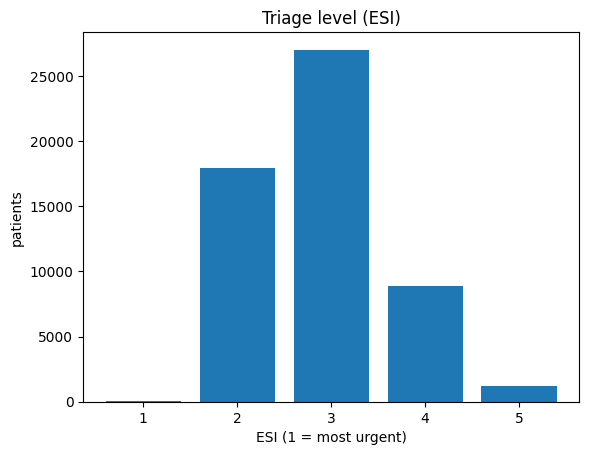

In [5]:
esi = df["esi"].value_counts().sort_index()
print(esi)

plt.bar(esi.index.astype(int).astype(str), esi.values)
plt.title("Triage level (ESI)"); plt.xlabel("ESI (1 = most urgent)"); plt.ylabel("patients")
plt.show()

ESI 3 (the middle band this project targets) is about 49% of patients. ESI 1 and 5 are rare.

### 5. Vital signs

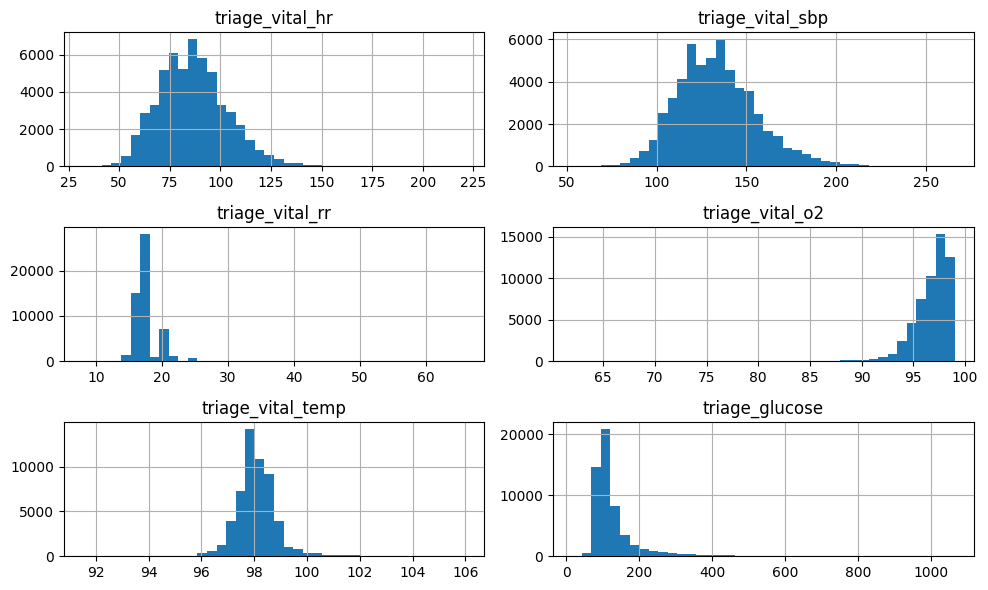

In [6]:
vitals = ["triage_vital_hr","triage_vital_sbp","triage_vital_rr",
          "triage_vital_o2","triage_vital_temp","triage_glucose"]
df[vitals].hist(bins=40, figsize=(10,6))
plt.tight_layout(); plt.show()

Vitals are all within plausible clinical ranges, no obvious errors.

### 6. Demographics (race and ethnicity)

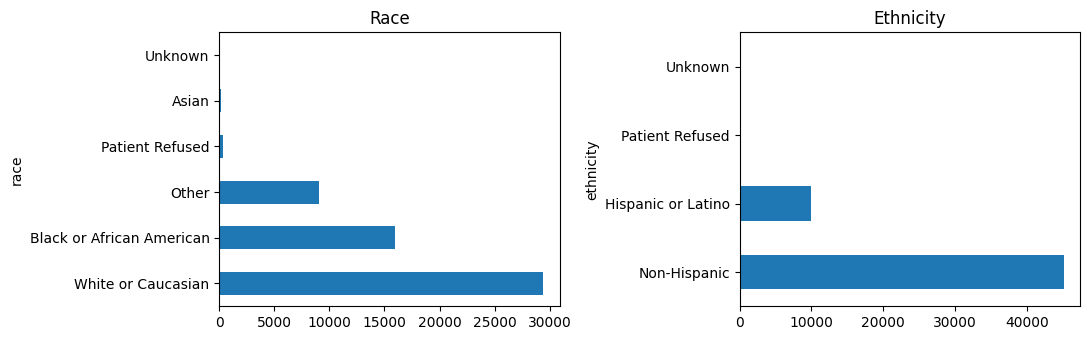

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
df["race"].value_counts().head(6).plot.barh(ax=ax[0], title="Race")
df["ethnicity"].value_counts().plot.barh(ax=ax[1], title="Ethnicity")
plt.tight_layout(); plt.show()

Single US academic ED: majority White, then Black, then Hispanic. Case-mix differs from a Caribbean setting, so a model would need local re-validation.

### 7. Chief complaints

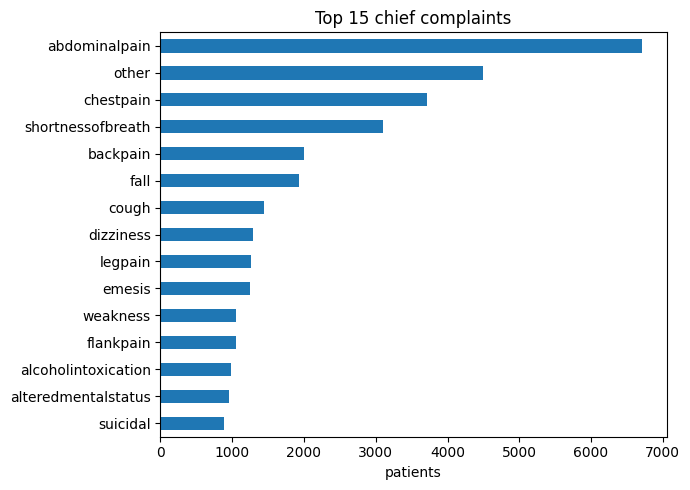

complaints with < 50 cases: 49 of 200


In [8]:
top = df[cc].sum().sort_values(ascending=False).head(15)
top.index = [x[3:] for x in top.index]   # drop the cc_ prefix
top[::-1].plot.barh(figsize=(7,5), title="Top 15 chief complaints")
plt.xlabel("patients"); plt.tight_layout(); plt.show()

# many complaints are rare
print("complaints with < 50 cases:", (df[cc].sum() < 50).sum(), "of", len(cc))

### 8. Correlation of chief complaints with triage level

In [9]:
cc_corr = df[cc + ["esi"]].corr()["esi"].drop("esi").dropna()
cc_corr = cc_corr.reindex(cc_corr.abs().sort_values(ascending=False).index).head(10)
cc_corr.index = [x[3:] for x in cc_corr.index]
print(cc_corr.round(3))
# negative = higher acuity (lower ESI). chest pain, SOB etc. line up with clinical sense

chestpain             -0.164
shortnessofbreath     -0.150
suicidal              -0.143
backpain               0.142
alcoholintoxication   -0.142
rash                   0.134
alteredmentalstatus   -0.132
dentalpain             0.127
kneepain               0.116
sorethroat             0.108
Name: esi, dtype: float64


### 9. Correlation of selected complaints with vitals

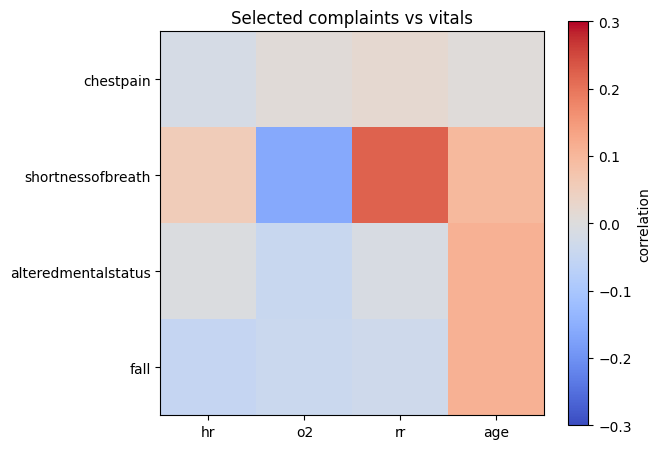

,triage_vital_hr,triage_vital_o2,triage_vital_rr,age
cc_chestpain,-0.018,0.009,0.021,0.007
cc_shortnessofbreath,0.054,-0.161,0.221,0.098
cc_alteredmentalstatus,-0.006,-0.044,-0.014,0.112
cc_fall,-0.051,-0.038,-0.031,0.111


In [10]:
sel = ["cc_chestpain","cc_shortnessofbreath","cc_alteredmentalstatus","cc_fall"]
m = df[sel + ["triage_vital_hr","triage_vital_o2","triage_vital_rr","age"]].corr()
m = m.loc[sel, ["triage_vital_hr","triage_vital_o2","triage_vital_rr","age"]]

plt.imshow(m, cmap="coolwarm", vmin=-0.3, vmax=0.3)
plt.xticks(range(4), ["hr","o2","rr","age"]); plt.yticks(range(4), [s[3:] for s in sel])
plt.colorbar(label="correlation"); plt.title("Selected complaints vs vitals")
plt.tight_layout(); plt.show()
m.round(3)

### 10. Top-10 predictive feature shortlist
Ranked by clinical sense plus correlation with ESI.

1. age - older patients are triaged more acutely (strongest numeric correlate)
2. triage_vital_o2 - low oxygen is an immediate red flag
3. triage_vital_rr - early marker of deterioration
4. triage_vital_hr - tachycardia signals shock or sepsis
5. triage_vital_sbp - low BP means instability
6. cc_chestpain - high chance of a serious cause
7. cc_shortnessofbreath - maps to breathing priority
8. cc_alteredmentalstatus - top acuity trigger
9. triage_glucose - extremes flag DKA or hypoglycaemia
10. arrivalmode - ambulance arrival signals higher acuity

### Verdict
Large (55,121 patients), complete, and the middle band (ESI 3) is about half the data, so it is good enough to build a baseline model. Caveats: pre-processed single US site, class imbalance at ESI 1 and 5, many rare complaint flags, and case-mix that will not transfer to a Caribbean setting without local validation.